**cargar datos**

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

# load data
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="diagnosis")

# original distribution
original_distribution = y.value_counts(normalize=True).sort_index()

print(original_distribution)

diagnosis
0    0.372583
1    0.627417
Name: proportion, dtype: float64


**función para comparar**

In [14]:
# compare distributions
def compare_distribution(original, result, name):
    result = result.sort_index()

    difference = (result - original).abs()
    max_difference = difference.max()

    print(f"--- {name} ---")
    print(result)
    print(f"max difference: {max_difference:.4f}")
    print()

    return max_difference

**probar 3 escenarios**

In [15]:
# experiment 1
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=915
)

distribution_1 = y_test.value_counts(normalize=True).sort_index()

difference_1 = compare_distribution(
    original_distribution,
    distribution_1,
    "experiment 1"
)


# experiment 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=99
)

distribution_2 = y_test.value_counts(normalize=True).sort_index()

difference_2 = compare_distribution(
    original_distribution,
    distribution_2,
    "experiment 2"
)


# experiment 3
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=7
)

distribution_3 = y_test.value_counts(normalize=True).sort_index()

difference_3 = compare_distribution(
    original_distribution,
    distribution_3,
    "experiment 3"
)

--- experiment 1 ---
diagnosis
0    0.175439
1    0.824561
Name: proportion, dtype: float64
max difference: 0.1971

--- experiment 2 ---
diagnosis
0    0.333333
1    0.666667
Name: proportion, dtype: float64
max difference: 0.0393

--- experiment 3 ---
diagnosis
0    0.336842
1    0.663158
Name: proportion, dtype: float64
max difference: 0.0357



**grafico**

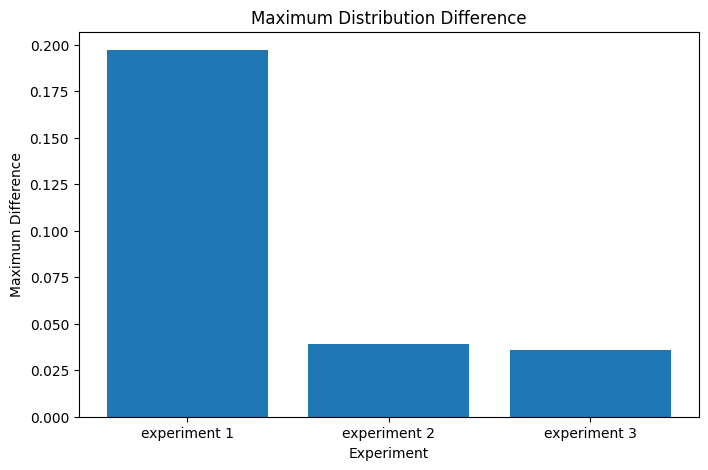

In [16]:
# plot maximum differences
names = ["experiment 1", "experiment 2", "experiment 3"]
differences = [difference_1, difference_2, difference_3]

plt.figure(figsize=(8, 5))

plt.bar(names, differences)

plt.title("Maximum Distribution Difference")
plt.ylabel("Maximum Difference")
plt.xlabel("Experiment")

plt.show()

**original vs random**

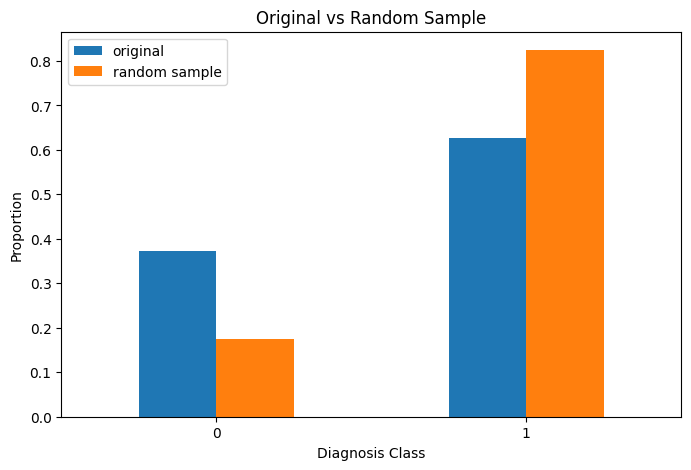

In [17]:
# compare original distribution with worst random sample
comparison = pd.DataFrame({
    "original": original_distribution,
    "random sample": distribution_1
})

comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Original vs Random Sample")
plt.xlabel("Diagnosis Class")
plt.ylabel("Proportion")
plt.xticks(rotation=0)

plt.show()

**stratify**

In [18]:
# stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=915,
    stratify=y
)

stratified_distribution = y_test.value_counts(
    normalize=True
).sort_index()

stratified_difference = compare_distribution(
    original_distribution,
    stratified_distribution,
    "stratified sampling"
)

--- stratified sampling ---
diagnosis
0    0.368421
1    0.631579
Name: proportion, dtype: float64
max difference: 0.0042



**gráfica final**

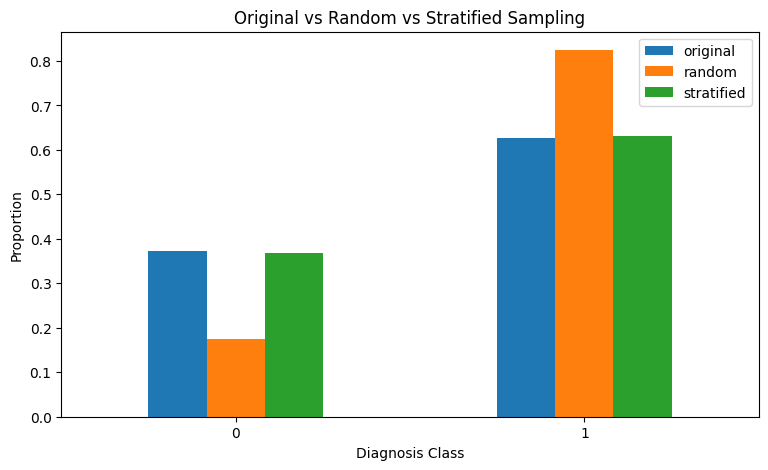

In [19]:
# compare all distributions
final_comparison = pd.DataFrame({
    "original": original_distribution,
    "random": distribution_1,
    "stratified": stratified_distribution
})

final_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Original vs Random vs Stratified Sampling")
plt.xlabel("Diagnosis Class")
plt.ylabel("Proportion")
plt.xticks(rotation=0)

plt.show()

**antes vs despues**

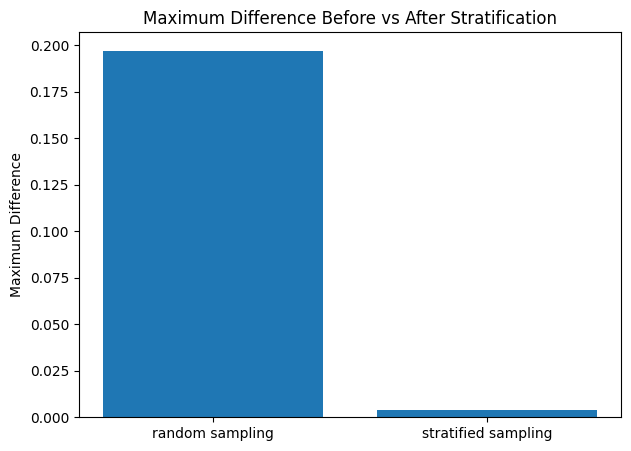

In [20]:
# compare maximum difference before and after stratification
methods = ["random sampling", "stratified sampling"]
differences = [difference_1, stratified_difference]

plt.figure(figsize=(7, 5))

plt.bar(methods, differences)

plt.title("Maximum Difference Before vs After Stratification")
plt.ylabel("Maximum Difference")

plt.show()

**conclusión**

el peor escenario encontrado utilizando muestreo aleatorio simple fue con test_size = 0.1 y random_state = 915. La diferencia máxima respecto a la distribución original fue aproximadamente 0.1971, es decir, alrededor de 19.7 puntos porcentuales.


Al utilizar la misma configuración pero agregando stratify=y, la diferencia máxima disminuyó aproximadamente a 0.0042.


Esto demuestra que el muestreo estratificado mantiene mucho mejor las proporciones de las clases del conjunto original.


Un test_size pequeño puede generar diferencias más extremas porque contiene menos observaciones. Con menos datos, cada registro representa una proporción mayor de la muestra y el azar tiene más influencia sobre la distribución final. En muestras más grandes, estas variaciones tienden a compensarse y la distribución suele parecerse más a la población original.